# Assignment 2 - Hugging Face transformers for FactNews

This notebook builds and evaluates **traditional machine learning** classifiers for the **FactNews** dataset, a Brazilian Portuguese sentence-level dataset for factuality and media-bias analysis.

This project was developed by Elton Tamele (up201908676@up.pt), Maureen Ah-shú (up201708043@up.pt), and Tomás Teixeira (up202208041@up.pt) for the Natural Language Processing course in MEIC, FEUP.

## Goals
..

## Classification tasks
This notebook works with the two formulations exposed by the **FactNews** repository:

- **Task A** - 3-class sentence classification
  - Labels: biased, factual, quote
- **Task B** - binary factuality design classification  
  - Labels: factual, non_factual

## Dataset provenance

According to the **FactNews** repository and the accompanying RANLP 2023 paper, the dataset:
- is in **Brazilian Portuguese**
- contains **6,191 annotated sentences**
- comes from **300 news documents** covering **100 news stories**
- uses three media outlets: **Folha de São Paulo**, **Estadão**, and **O Globo**
- covers domains such as **politics, world, sports, daily, culture, and science**
- includes sentence-level annotations for:
  - **factual spans** as 0
  - **biased spans** as 1
  - **quotes** as -1

The original paper reports the following strong baselines:
- **Sentence-level factuality prediction**: **F1 = 0.88** with fine-tuned BERT
- **Sentence-level media bias prediction**: **F1 = 0.67** with fine-tuned BERT

Since this assignment forbids deep learning architectures such as Transformers, those values are used **only as contextual reference**, not as target models.

### References
- Repository: [franciellevargas/FactNews](https://github.com/franciellevargas/FactNews)
- Paper: *Predicting Sentence-Level Factuality of News and Bias of Media Outlets* (RANLP 2023)

## Environment Preparation

In [1]:
!pip install -q \
    "datasets>=3.0.0" \
    "transformers>=4.44.0" \
    "accelerate>=0.34.0" \
    pandas numpy matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.7 MB/s eta 0:00:00


In [2]:
# If needed, uncomment the next line to install dependencies.
%pip install pandas==2.2.2 numpy==2.0.2 matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn -q
!pip install transformers datasets accelerate -q

import re
import warnings
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report,accuracy_score,f1_score,confusion_matrix)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch
import gc

import pickle
from google.colab import drive
drive.mount('/content/drive')



SAVE_DIR = "/content/drive/MyDrive/pln_results/"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Mounted at /content/drive


## Load Data

In [3]:
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset_factuality_design.csv"

df_main = pd.read_csv("factnews_dataset.csv")
df_fact = pd.read_csv("factnews_dataset_factuality_design.csv")

print("Main dataset shape:", df_main.shape)
print("Factuality-design dataset shape:", df_fact.shape)

Main dataset shape: (6191, 7)
Factuality-design dataset shape: (6191, 7)


### Column description

From inspection, both files have the same schema:

- `file`: original document identifier
- `id_sente`: sentence identifier
- `id_article`: article/story identifier
- `domain`: news domain
- `year`: publication year
- `sentences`: sentence text
- `classe`: label

The difference is in the meaning of `classe`:
- in the **main dataset** it encodes the 3-way annotation
- in the **factuality design dataset** it encodes the binary factuality design

## Pre-processing

The preprocessing used in this notebook is intentionally simple and easy to justify:

- lowercase
- remove URLs
- remove digits
- remove punctuation/special symbols
- normalize whitespace

This is a reasonable baseline for short news sentences in Portuguese.  
We avoid aggressive stemming/lemmatization here because:
1. the dataset is not extremely large,
2. some wording choices may carry bias cues,
3. simple normalization makes it easier to interpret model errors.

In [4]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("“", '"').replace("”", '"').replace("‘", "'").replace("’", "'")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\sÀ-ÿ\"']", " ", text)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for frame in (df_main, df_fact):
    frame["text_clean"] = frame["sentences"].apply(clean_text)
    frame["n_chars"] = frame["sentences"].astype(str).str.len()
    frame["n_words"] = frame["text_clean"].str.split().str.len()
    frame["n_double_quotes"] = (frame["sentences"].astype(str).str.replace("“", '"', regex=False).str.replace("”", '"', regex=False).str.count('"'))
    frame["n_single_quotes"] = (frame["sentences"].astype(str).str.replace("‘", "'", regex=False).str.replace("’", "'", regex=False).str.count("'"))
    frame["has_quotes"] = ((frame["n_double_quotes"] + frame["n_single_quotes"]) > 0).astype(int)

main_label_map = {-1: "quote", 0: "factual", 1: "biased"}
fact_label_map = {0: "factual", 1: "non_factual"}

df_main["label"] = df_main["classe"].map(main_label_map)
df_fact["label"] = df_fact["classe"].map(fact_label_map)

display(
    df_main[
        ["sentences", "text_clean", "label", "has_quotes"]
    ].head()
)

,sentences,text_clean,label,has_quotes
0,"""Não houve sobreviventes"", disse Okala.","""não houve sobreviventes"" disse okala",quote,1
1,As vítimas do acidente foram 14 passageiros e ...,as vítimas do acidente foram passageiros e trê...,factual,0
2,"O avião explodiu e se incendiou, acrescentou o...",o avião explodiu e se incendiou acrescentou o ...,factual,0
3,"O porta-voz informou que o avião, um Soviet An...",o porta voz informou que o avião um soviet ant...,factual,0
4,"Segundo fontes aeroportuárias, os membros da t...",segundo fontes aeroportuárias os membros da tr...,factual,0


## Exploratory Data Analysis

In [5]:
print("Task A - Main label distribution:")
display(df_main["label"].value_counts().rename_axis("label").reset_index(name="count"))

print("Task B - Binary factuality label distribution:")
display(df_fact["label"].value_counts().rename_axis("label").reset_index(name="count"))

Task A - Main label distribution:


,label,count
0,factual,4242
1,quote,1391
2,biased,558


Task B - Binary factuality label distribution:


,label,count
0,factual,4242
1,non_factual,1949


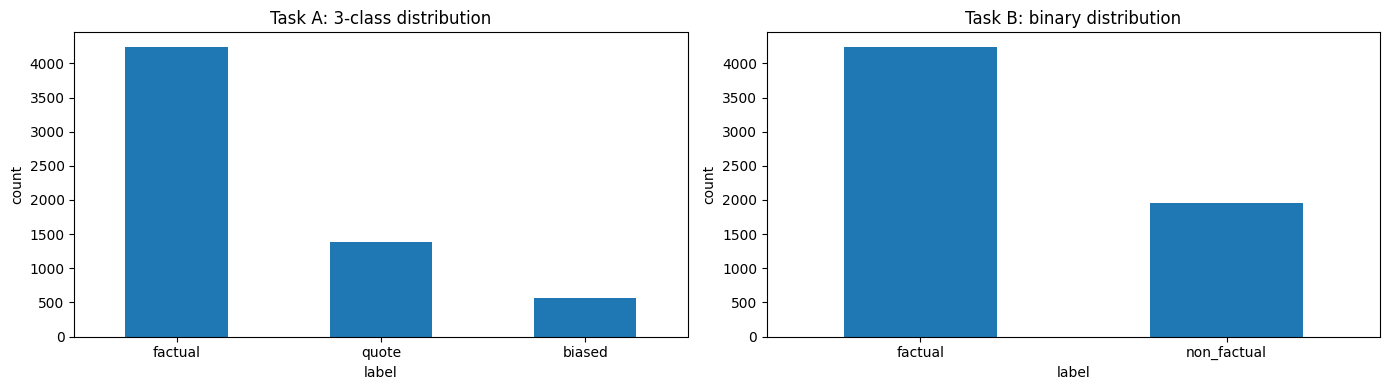

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_main["label"].value_counts().plot(kind="bar", ax=axes[0], title="Task A: 3-class distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

df_fact["label"].value_counts().plot(kind="bar", ax=axes[1], title="Task B: binary distribution")
axes[1].set_xlabel("label")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Data Preparation

In [7]:
import pandas as pd
from sklearn.utils import shuffle
from datasets import Dataset

# 1. Carregar os dados sintéticos gerados pelo Gemini
# (Assumimos que o df_main já foi carregado e dividido no início do notebook em train_df e test_df)
df_augmented = pd.read_csv("factnews_augmented_instances.csv")

# 2. Mapeamento das labels sintéticas para a convenção numérica do notebook (label_id)
# No teu notebook: 0 = biased, 1 = factual, 2 = quote
hf_label_map = {'biased': 0, 'factual': 1, 'quote': 2}
df_augmented['label_id'] = df_augmented['label'].map(hf_label_map)

# Manter apenas as colunas que interessam ('sentences' e 'label_id') para juntar ao train_df
df_augmented = df_augmented[['sentences', 'label_id']]

# 3. Concatenar os dados de treino originais (train_df) com os dados sintéticos (df_augmented)
# Nota: Só adicionamos ao treino, o test_df mantém-se inalterado com dados reais
train_balanced_ai = pd.concat([train_df[['sentences', 'label_id']], df_augmented], ignore_index=True)

# Baralhar (shuffle) para o modelo não aprender padrões de ordenação
train_balanced_ai = train_balanced_ai.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribuição após Data Augmentation (Train Set):")
print(train_balanced_ai['label_id'].value_counts())

# 4. Criar o Dataset do Hugging Face e aplicar o Tokenizer
# Estou a usar as variáveis e funções (tokenize / tokenize_bi) do teu código original
train_ds_ai = Dataset.from_pandas(
    train_balanced_ai.rename(columns={"label_id": "labels"})
)

# SE FORES TREINAR O mBERT:
train_ds_ai = train_ds_ai.map(tokenize, batched=True)
train_ds_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

FileNotFoundError: [Errno 2] No such file or directory: 'factnews_augmented_instances.csv'

In [ ]:
train_df, test_df = train_test_split(
    df_main, test_size=0.2, random_state=42, stratify=df_main["label_id"]
)

## Free memory function

In [ ]:
TARGET_NAMES = ["biased", "factual", "quote"]

def free_memory(*models):
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")


def save_results(name, y_true, y_pred):
    data = {"y_true": y_true, "y_pred": y_pred}
    with open(f"{SAVE_DIR}{name.replace(' ', '_')}.pkl", "wb") as f:
        pickle.dump(data, f)
    print(f"Saved: {name}")

## Hugging Face Transformers

[Hugging Face](https://huggingface.co) is an open-source platform that provides
a central hub for sharing pre-trained machine learning models and datasets.
Its core library, `transformers`, offers a unified API to load, fine-tune, and
evaluate thousands of pre-trained models for Natural Language Processing tasks.

To select appropriate models for this task, we searched the Hugging Face Hub
for models compatible with Brazilian Portuguese and suitable for sequence
classification. This led us to the following two models, which will be
evaluated and compared throughout this notebook:

- **mBERT** (`google-bert/bert-base-multilingual-cased`): a multilingual BERT
  model pre-trained on Wikipedia across 104 languages, including Portuguese.
- **BERTimbau** (`neuralmind/bert-base-portuguese-cased`): a BERT model
  pre-trained exclusively on Brazilian Portuguese data (BrWaC corpus).

Each model is explored in detail in the sections below.

**Imbalaced**

Como um dos nossos principais problemas na última entrega foi conseguir mitigar os problemas que o desblanceamento do dataset nos causou, decidimos testar mais técnicas para lidar com este problema. Essas técnicas testadas foram as seguintes:

- Without resampling: Já presente na última entrega
- Manual Oversampling: Já presente na última entrega
- Class weight in loss: Já presente na última entrega
-

### mBert


**mBERT** (`google-bert/bert-base-multilingual-cased`) is a multilingual
version of BERT (Bidirectional Encoder Representations from Transformers),
introduced by Devlin et al. (2019). It was pre-trained on Wikipedia text
from 104 languages simultaneously, including Portuguese, using Masked
Language Modelling (MLM) and Next Sentence Prediction (NSP).

Despite not being specifically designed for Portuguese, mBERT serves as a
strong multilingual baseline for NLP tasks across many languages. It contains
**179M parameters** and uses a cased WordPiece tokenizer shared across all
104 languages.

In [ ]:
results = {}

MODEL_NAME = "google-bert/bert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

### Without resampling

In [ ]:
training_args = TrainingArguments(
    output_dir="./mbert_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,          # GPU no Colab — acelera o treino
    seed=42,
    logging_steps=50,
    report_to="none"    # desativa wandb
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

In [ ]:
TARGET_NAMES = ["biased", "factual", "quote"]

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Base", y_true, y_pred)


free_memory(model)

#### Manual Oversampling

In [ ]:
train_biased  = train_df[train_df["label_id"] == 0]
train_factual = train_df[train_df["label_id"] == 1]
train_quote   = train_df[train_df["label_id"] == 2]

train_biased_up = resample(train_biased, replace=True,
                           n_samples=len(train_factual), random_state=42)
train_quote_up  = resample(train_quote,  replace=True,
                           n_samples=len(train_factual), random_state=42)

train_balanced = pd.concat([train_factual, train_biased_up, train_quote_up])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)



train_ds_os = Dataset.from_pandas(
    train_balanced[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_os = train_ds_os.map(tokenize, batched=True)
train_ds_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])



model_os = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_os = Trainer(
    model=model_os,
    args=training_args,
    train_dataset=train_ds_os,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 2: Oversampling ===")
trainer_os.train()


preds_os = trainer_os.predict(test_ds)
y_pred_os = np.argmax(preds_os.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_os,
      target_names=["biased", "factual", "quote"]))


preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Oversampling", y_true, y_pred)


free_memory(model_os)

#### Class weights in loss

In [ ]:
weights = compute_class_weight("balanced",
                               classes=np.array([0, 1, 2]),
                               y=train_df["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

model_cw = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_cw = WeightedTrainer(
    model=model_cw,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 3: Class Weights ===")
trainer_cw.train()

preds_cw = trainer_cw.predict(test_ds)
y_pred_cw = np.argmax(preds_cw.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_cw,
      target_names=["biased", "factual", "quote"]))



preds_output = trainer.predict(test_ds)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred_cw, target_names=TARGET_NAMES))


save_results("mBERT - Class weight in loss", y_true, y_pred_cw)


free_memory(model_cw)

####  Synthetic Data Augmentation

In [ ]:
train_ds_ai = Dataset.from_pandas(
    train_balanced_ai.rename(columns={"label_id": "labels"})
)
train_ds_ai = train_ds_ai.map(tokenize, batched=True)
train_ds_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

model_ai = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

trainer_ai = Trainer(
    model=model_ai,
    args=training_args,
    train_dataset=train_ds_ai,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)


trainer_ai.train()

preds_ai = trainer_ai.predict(test_ds)
y_pred_ai = np.argmax(preds_ai.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred_ai,
    target_names=["biased", "factual", "quote"]
))

save_results("mBERT - Synthetic Augmentation", y_true, y_pred_ai)
free_memory(model_ai)

### BERTimbau

#### Without Sampling

In [ ]:
# ── BERTimbau ────────────────────────────────────────────────────────────────
BERTIMBAU_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer_bi = AutoTokenizer.from_pretrained(
    BERTIMBAU_NAME,
    do_lower_case=False
)

def tokenize_bi(batch):
    return tokenizer_bi(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])


model_bi = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi = Trainer(
    model=model_bi,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

trainer_bi.train()

preds_bi = trainer_bi.predict(test_ds_bi)
y_pred_bi = np.argmax(preds_bi.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi,
    target_names=["biased", "factual", "quote"]
))

print(classification_report(y_true, y_pred_bi, target_names=TARGET_NAMES))


save_results("BERTimbau - Base", y_true, y_pred_bi)


free_memory(model_bi)

#### Manual Oversampling

In [ ]:
# ── BERTimbau: Oversampling Manual ───────────────────────────────────────────
train_biased_bi  = train_df[train_df["label_id"] == 0]
train_factual_bi = train_df[train_df["label_id"] == 1]
train_quote_bi   = train_df[train_df["label_id"] == 2]

train_biased_up_bi = resample(train_biased_bi, replace=True,
                               n_samples=len(train_factual_bi), random_state=42)
train_quote_up_bi  = resample(train_quote_bi,  replace=True,
                               n_samples=len(train_factual_bi), random_state=42)

train_balanced_bi = pd.concat([train_factual_bi, train_biased_up_bi, train_quote_up_bi])
train_balanced_bi = train_balanced_bi.sample(frac=1, random_state=42).reset_index(drop=True)

# Tokenizar o dataset balanceado
train_ds_bi_os = Dataset.from_pandas(
    train_balanced_bi[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_bi_os = train_ds_bi_os.map(tokenize_bi, batched=True)
train_ds_bi_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Modelo limpo
model_bi_os = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

trainer_bi_os = Trainer(
    model=model_bi_os,
    args=training_args,
    train_dataset=train_ds_bi_os,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Oversampling ===")
trainer_bi_os.train()

preds_bi_os = trainer_bi_os.predict(test_ds_bi)
y_pred_bi_os = np.argmax(preds_bi_os.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_os,
    target_names=["biased", "factual", "quote"]
))


save_results("BERTimbau - Oversampling", y_true, y_pred_bi_os)


free_memory(model_bi_os)

#### Class Weight in loss

In [ ]:

model_bi_cw = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi_cw = WeightedTrainer(
    model=model_bi_cw,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Class Weights ===")
trainer_bi_cw.train()

preds_bi_cw = trainer_bi_cw.predict(test_ds_bi)
y_pred_bi_cw = np.argmax(preds_bi_cw.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_cw,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Class Weight", y_true, y_pred_bi_cw)


free_memory(model_bi_cw)

### Load models

In [ ]:
with open(f"{SAVE_DIR}results.pkl", "rb") as f:
    results = pickle.load(f)

print("Models saved:")
for name, v in results.items():
    print(f"  {name} → F1 Macro: {v['f1_macro']:.4f}")